# 01 探索性数据分析 (EDA)

参考项目：`/home/ye/data-science/Kaggle-Home-Credit-Default-Risk-Solution/EDA.ipynb`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = '/home/ye/data-science/home-credit-default-risk/data/'
application_train = DATA_DIR + "application_train.csv"
df = pd.read_csv(application_train)
shape = df.shape
head = df.head()
info = df.info()
des = df.describe()
print(shape)
print("="*60)
print(head)
print("="*60)
print(info)
print("="*60)
print(des)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
(307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0  

In [31]:
print(des)

          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL  \
count  307511.000000  307511.000000  307511.000000      3.075110e+05   
mean   278180.518577       0.080729       0.417052      1.687979e+05   
std    102790.175348       0.272419       0.722121      2.371231e+05   
min    100002.000000       0.000000       0.000000      2.565000e+04   
25%    189145.500000       0.000000       0.000000      1.125000e+05   
50%    278202.000000       0.000000       0.000000      1.471500e+05   
75%    367142.500000       0.000000       1.000000      2.025000e+05   
max    456255.000000       1.000000      19.000000      1.170000e+08   

         AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  3.075110e+05  307499.000000     3.072330e+05   
mean   5.990260e+05   27108.573909     5.383962e+05   
std    4.024908e+05   14493.737315     3.694465e+05   
min    4.500000e+04    1615.500000     4.050000e+04   
25%    2.700000e+05   16524.000000     2.385000e+05   
50%    5.135310e+05  

In [32]:
(df['AMT_INCOME_TOTAL'] >= 1000000 ).sum()

np.int64(250)

In [26]:
object_columns = df.select_dtypes(include='object')
object_columns_name = object_columns.columns
print(object_columns_name)

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [4]:
object_columns_nunique = []
for i in object_columns_name:
    object_columns_nunique.append(df[i].nunique())
print(object_columns_nunique)

[2, 3, 2, 2, 7, 8, 5, 6, 6, 18, 7, 58, 4, 3, 7, 2]


In [5]:
missing_count = df.isnull().sum()
missing_gt0 = missing_count[missing_count>0]

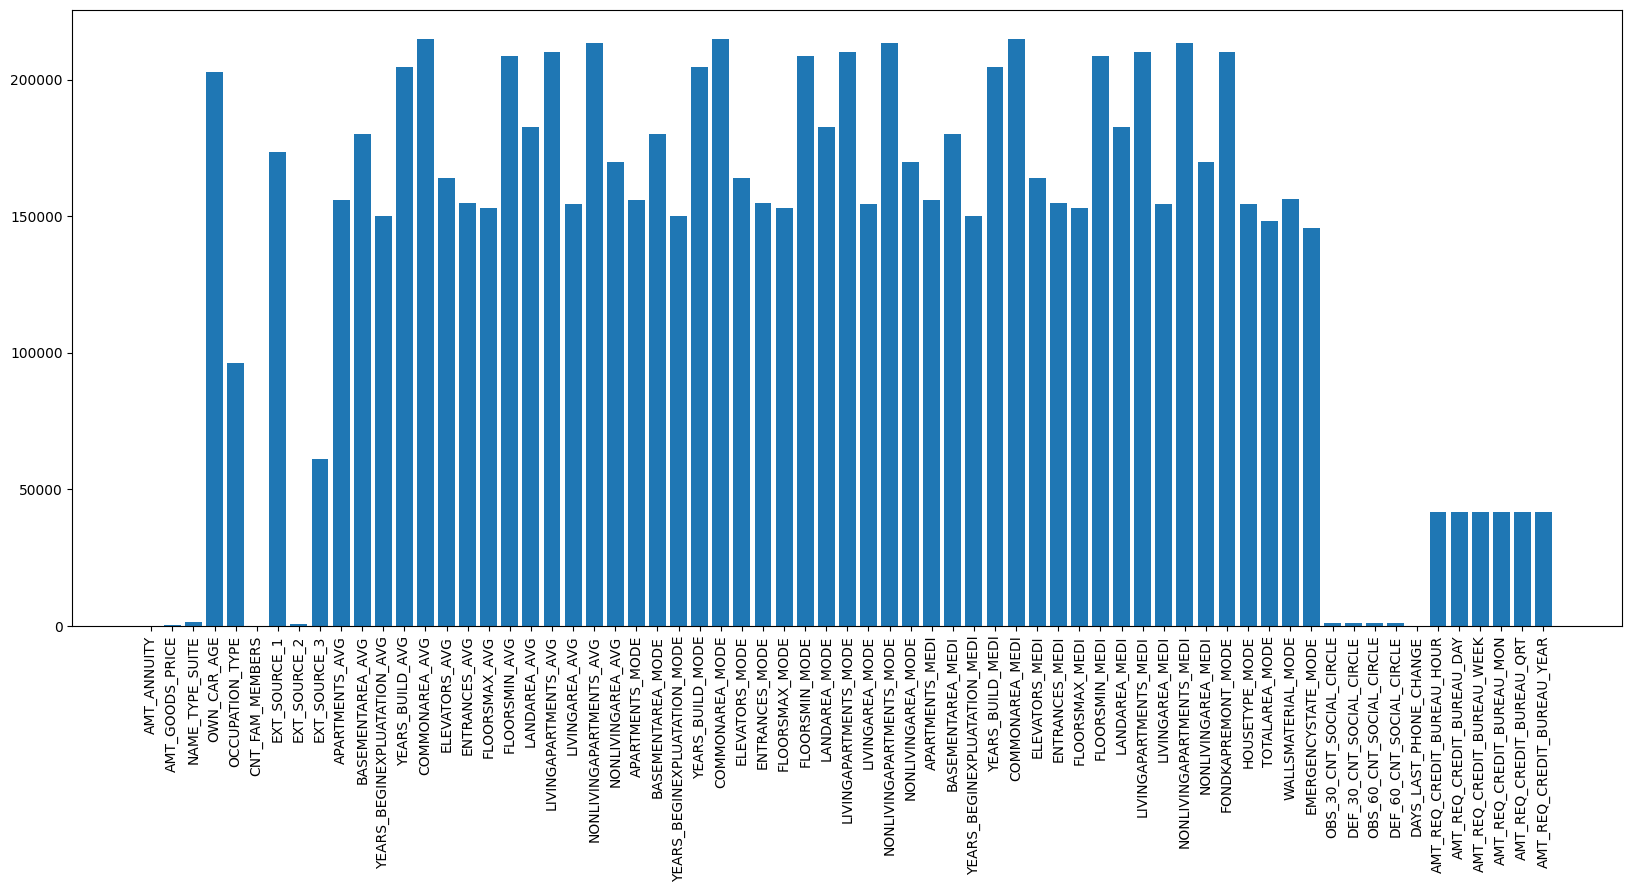

In [6]:

plt.figure(figsize=(20,8))
plt.bar(missing_gt0.index,missing_gt0.values)
plt.xticks(rotation=90)
plt.show()



In [18]:
corr = df.corr(numeric_only=True)['TARGET'].sort_values(ascending=False)

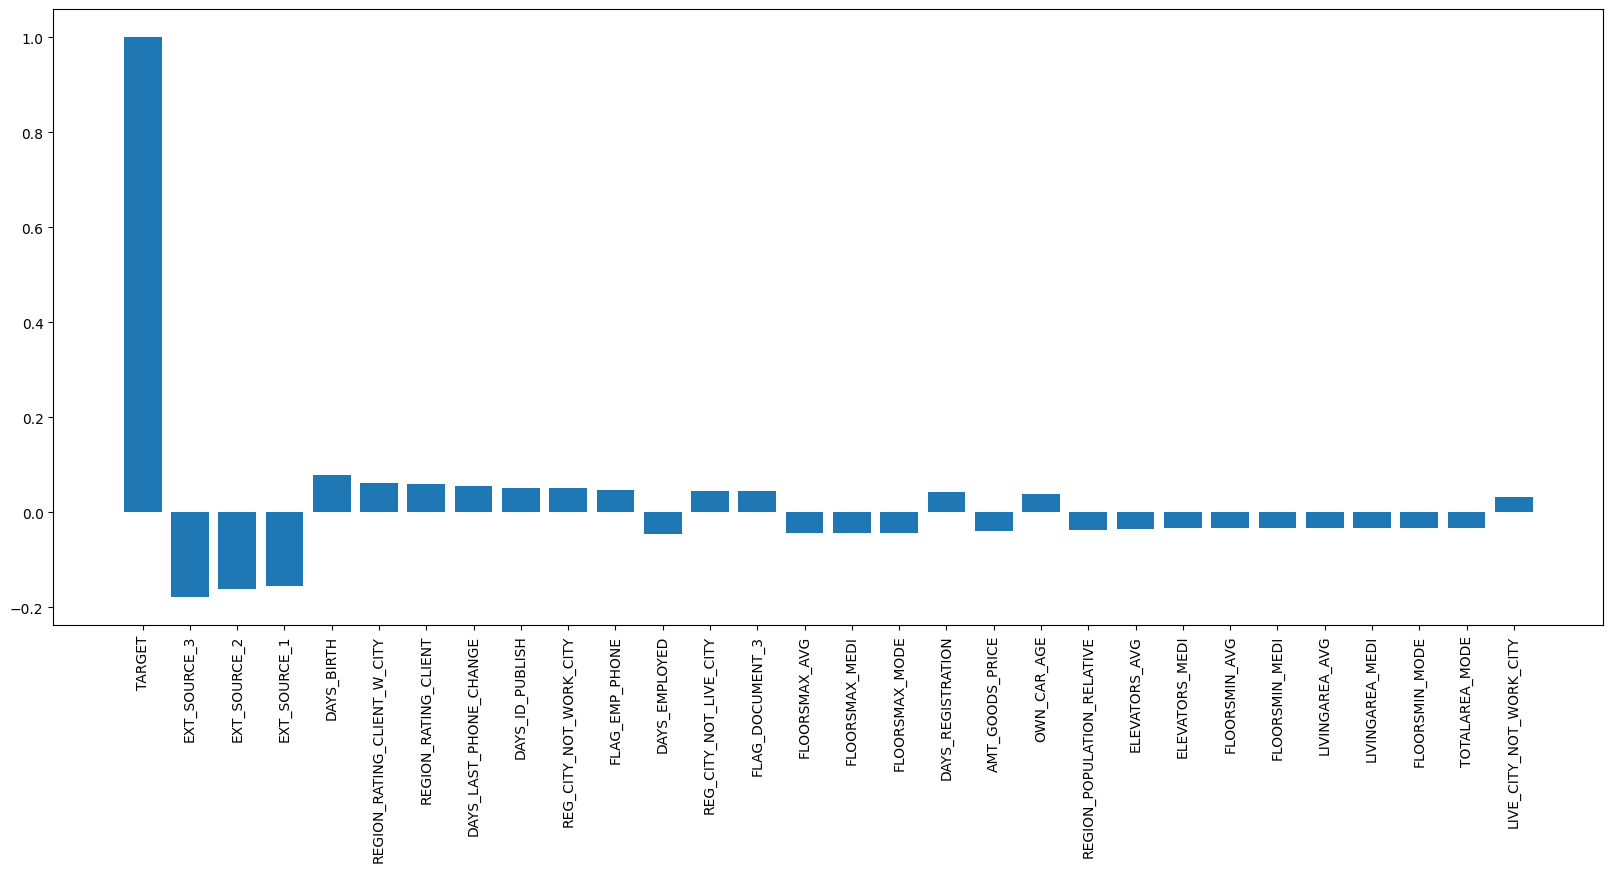

In [20]:

corr_abs30_name = corr.abs().sort_values(ascending=False)[0:30].index
plt.figure(figsize=(20,8))
plt.bar(corr_abs30_name,corr[corr_abs30_name])
plt.xticks(rotation=90)
plt.show()

In [23]:
df.groupby('CODE_GENDER')['TARGET'].mean()

CODE_GENDER
F      0.069993
M      0.101419
XNA    0.000000
Name: TARGET, dtype: float64

In [24]:
df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean()

NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64

In [29]:
for i in object_columns_name:
    print(df.groupby(i)['TARGET'].agg(['mean','count']))
    print("="*60)

                        mean   count
NAME_CONTRACT_TYPE                  
Cash loans          0.083459  278232
Revolving loans     0.054783   29279
                 mean   count
CODE_GENDER                  
F            0.069993  202448
M            0.101419  105059
XNA          0.000000       4
                  mean   count
FLAG_OWN_CAR                  
N             0.085002  202924
Y             0.072437  104587
                     mean   count
FLAG_OWN_REALTY                  
N                0.083249   94199
Y                0.079616  213312
                     mean   count
NAME_TYPE_SUITE                  
Children         0.073768    3267
Family           0.074946   40149
Group of people  0.084871     271
Other_A          0.087760     866
Other_B          0.098305    1770
Spouse, partner  0.078716   11370
Unaccompanied    0.081830  248526
                          mean   count
NAME_INCOME_TYPE                      
Businessman           0.000000      10
Commercial associat

In [30]:
(df['DAYS_EMPLOYED'] >= 365243 ).sum()

np.int64(55374)

<Axes: xlabel='EXT_SOURCE_2', ylabel='Density'>

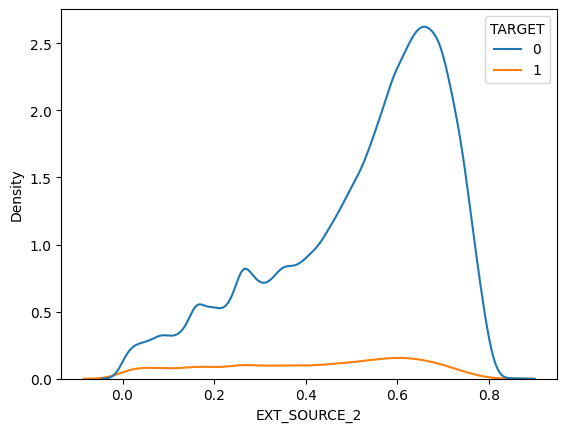

In [33]:
sns.kdeplot(data=df, x='EXT_SOURCE_2', hue='TARGET')

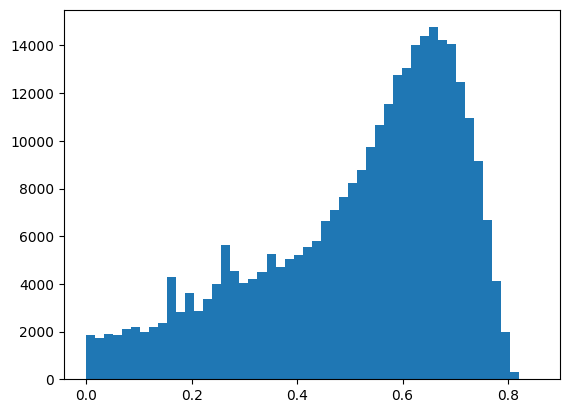

In [3]:
plt.hist(df['EXT_SOURCE_2'].dropna(), bins=50)
plt.show()

<Axes: xlabel='AMT_INCOME_TOTAL', ylabel='AMT_CREDIT'>

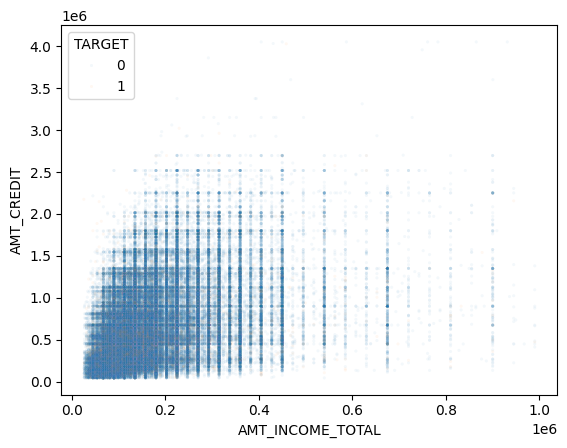

In [6]:
df_filtered = df[df['AMT_INCOME_TOTAL'] < 1000000]
sns.scatterplot(data=df_filtered, x='AMT_INCOME_TOTAL', y='AMT_CREDIT', hue='TARGET', alpha=0.05, s=5)

